# GK2A AMI SW038 다음 프레임 예측 (ConvLSTM)

2분 간격 위성영상 **하루치 710장**(2025-10-17 UTC 00:00~23:58)을 이용한 **next-frame prediction** 파이프라인.

1. 데이터 적재 · 연속 구간(segment) 분리 · 정규화 · Persistence 베이스라인
2. 패치 슬라이딩 윈도우 데이터셋 생성
3. ConvLSTM2D(**잔차 + SSIM 손실**) 학습 · 예측 · 시각화

데이터는 `gk2a_download.py` 로 AWS Open Data(`s3://noaa-gk2a-pds`, 익명 접근)에서 받는다.

```bash
python3 gk2a_download.py --date 2025-10-17 --channel sw038 --out resource/netcdf
```

> **실행 전 참고**
> - **Keras 2 와 Keras 3 양쪽에서 동작한다.** (검증: TF 2.15/Keras 2.15, TF 2.21/Keras 3.15)
>   Keras 3(TensorFlow 2.16 이상 — Colab 기본)의 ConvLSTM 은 입력 높이/너비에 `None` 을 허용하지 않는다.
>   그래서 모델을 **크기 고정**으로 만들고, 추론할 때 전체 크기 모델을 새로 만들어 가중치를 옮긴다.
>   `keras.Input(shape=(4, None, None, 1))` 로 두면 Colab 에서 다음 에러가 난다.
>   `ValueError: ConvLSTM layers only support static input shapes for the spatial dimension.`
> - (A) M1 GPU 가속을 쓰려면 `tensorflow-metal` 설치 필요.
> - (C) 입력은 500 -> 250 으로 다운샘플한다. `TARGET` 은 **원본 500 의 정수배 약수**여야 한다
>   (300 을 넣으면 `500//300 == 1` 이라 평균풀링이 아니라 **좌상단 크롭**이 되어 영역의 64% 가 조용히 버려진다).
> - M1 Pro 기준 **1 epoch 약 4분**(5,022 샘플 / batch 16 = 314 step). 20 epoch 면 약 80분이다.
>   빠른 확인은 `EPOCHS = 2` 로도 충분하다 — 아래 실측처럼 2 epoch 만으로 베이스라인을 넘는다.

> **하루치로 늘리면 달라지는 것**
> 30장(1시간)짜리로는 Persistence(다음=현재) 베이스라인을 이기기 어려웠다.
> 710장으로 늘리자 **2 epoch 만에 베이스라인을 넘는다**(M1 Pro 실측):
>
> | | MAE | SSIM |
> |---|---|---|
> | Persistence | 0.00623 | 0.9595 |
> | **ConvLSTM (2 epoch)** | **0.00453** | **0.9859** |
>
> full-frame 250×250 예측에서도 MAE 0.01091 → 0.00748 로 31% 개선된다.

> **이 데이터의 두 가지 함정**
> 1. **관측 결측**: 하루 720장 중 710장만 존재한다(위성 정기 점검으로 05:58→06:10, 21:08→21:20 각 5장 결측).
>    인덱스를 연속으로 가정하고 윈도우를 만들면 **12분 점프를 2분 변화로 착각해 학습**한다.
>    아래에서 `find_segments()` 로 연속 구간을 나눠 그 안에서만 윈도우를 만든다.
> 2. **주야 전환**: sw038(단파적외)은 주간에 태양 반사 성분이 더해져 값 분포가 달라진다.
>    실측하면 주간(00~06 UTC = 09~15 KST) 프레임간 MAE 가 야간의 **2.6배**다.
>    한 모델로 주야를 함께 학습하는 셈이므로, 조건을 통일하려면 `HOURS` 로 시간대를 제한하면 된다.

In [ ]:
import glob, os, re, time
from datetime import datetime, timedelta

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

%matplotlib inline
plt.close('all')

# 한글 폰트 설정 (macOS 기준)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

DATA_DIR = 'resource/netcdf'   # GK2A LA(한반도) 500x500, 2분 간격 하루치
VAR = 'image_pixel_values'

IN_FRAMES = 4     # 입력 시퀀스 길이 (과거 N장)
TARGET = 250      # (C) 다운샘플 해상도. 500 -> 250 (정수배 2). None 이면 원본 500 유지
PATCH = 96        # 패치 한 변 크기
STRIDE = 77       # 250 = 154 + 96 -> stride 77 이면 3x3 격자로 전 영역을 덮는다
                  #   (stride 96 이면 2x2 격자에 좌상단 59% 만 학습된다)
FILTERS = 16      # ConvLSTM 필터 수 (키우면 표현력↑ 속도↓)
EPOCHS = 4       # M1 Pro 기준 1 epoch 약 4분. 2 epoch 만으로도 베이스라인은 넘는다
BATCH = 16
HOURS = None      # 사용할 UTC 시각. None 이면 24시간 전부.
                  # 주간 태양반사를 빼려면 range(6, 24) (= 15~08 KST)
SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)
print('tf', tf.__version__)

tf 2.15.0


In [2]:
# (A) M1 GPU(Metal) 확인 + mixed precision 활성화
#  - GPU가 '없음'이면:  !pip install tensorflow-metal==1.1.0  후 커널 재시작
gpus = tf.config.list_physical_devices('GPU')
print('GPU:', gpus if gpus else '없음 (CPU) — tensorflow-metal 설치 필요')

# M1은 compute capability<7.0 이라 mixed precision 효과가 제한적일 수 있다.
# 불안정하거나 도움이 안 되면 아래 한 줄을 주석 처리(float32)해도 된다.
keras.mixed_precision.set_global_policy('mixed_float16')
print('precision policy:', keras.mixed_precision.global_policy().name)

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Your GPU may run slowly with dtype policy mixed_float16 because it does not have compute capability of at least 7.0. Your GPU:
  METAL, no compute capability (probably not an Nvidia GPU)
See https://developer.nvidia.com/cuda-gpus for a list of GPUs and their compute capabilities.
If you will use compatible GPU(s) not attached to this host, e.g. by running a multi-worker model, you can ignore this warning. This message will only be logged once
precision policy: mixed_float16


In [3]:
# ============================================================================
# 이 셀이 하는 일: .nc 파일 더미 -> 학습에 쓸 수 있는 (T, H, W) 배열 한 덩어리
#   1) 파일 목록을 관측 시각 순으로 줄 세운다
#   2) 시각을 파싱해 '결측으로 끊긴 지점'을 찾아 연속 구간으로 나눈다
#   3) 500x500 을 250x250 으로 줄인다
# ============================================================================

# 파일명 끝의 12자리 = 관측 시각(YYYYMMDDHHMM).
#   예: gk2a_ami_le1b_sw038_la020ge_202510171500.nc  ->  '202510171500'
# 파일마다 정규식을 새로 컴파일하지 않도록 한 번만 만들어 재사용한다.
STAMP_RE = re.compile(r'(\d{12})\.nc$')


def list_nc_files(data_dir):
  """디렉터리의 sw038 파일을 관측 시각 오름차순으로 반환."""
  files = glob.glob(os.path.join(data_dir, 'gk2a*sw038*.nc'))
  # 정렬 키로 '202510171500' 같은 문자열을 그대로 쓴다.
  # 자리수가 12로 고정이고 0 으로 패딩돼 있어 '사전순 == 시간순' 이 성립하기 때문이다.
  #   '202510170800' < '202510170958' < '202510171000'   (문자열 비교로도 순서가 맞다)
  # 형식이 안 맞는 파일은 키가 '' 이 되어 맨 앞으로 밀리고, parse_stamp 에서 걸린다.
  return sorted(files, key=lambda p: STAMP_RE.search(p).group(1) if STAMP_RE.search(p) else '')


def parse_stamp(path):
  """파일 경로 -> datetime. 아래 결측 판정에서 '간격이 2분인가'를 빼기로 확인하려고 시각 객체로 만든다."""
  return datetime.strptime(STAMP_RE.search(path).group(1), '%Y%m%d%H%M')


files = list_nc_files(DATA_DIR)
if not files:
  # 여기서 멈추지 않으면 바로 아래 stamps[0] 에서 IndexError 가 나 원인을 알기 어렵다.
  raise FileNotFoundError(f'{DATA_DIR} 에 gk2a*sw038*.nc 가 없다. gk2a_download.py 로 먼저 받아라.')

stamps = [parse_stamp(f) for f in files]

# HOURS 필터: 특정 UTC 시각대만 남긴다.
#   sw038 은 주간에 태양 반사가 섞여 값 분포가 달라지므로, 주야 조건을 통일하고 싶을 때 쓴다.
#   files 와 stamps 를 '같은 인덱스 목록으로' 함께 걸러야 둘의 짝이 어긋나지 않는다.
if HOURS is not None:
  keep = [i for i, s in enumerate(stamps) if s.hour in set(HOURS)]   # set 이라 in 검사가 O(1)
  files, stamps = [files[i] for i in keep], [stamps[i] for i in keep]

print(f'파일 수: {len(files)}')
print(f'기간   : {stamps[0]:%Y-%m-%d %H:%M} ~ {stamps[-1]:%H:%M} UTC')

# 파일을 하나씩 열어 2차원 배열을 꺼내고, 시간축으로 쌓아 (T, H, W) 를 만든다.
#   - astype(np.float32): 원본이 uint16 이라 그대로 두면 정규화·평균에서 정수 연산 문제가 생긴다
#   - 710장이면 이 줄에서 순간적으로 약 1.4GB 를 쓴다 (리스트와 stack 결과가 동시에 존재)
frames = np.stack([xr.open_dataset(f)[VAR].values.astype(np.float32) for f in files], axis=0)
print('원본 frames:', frames.shape, frames.dtype)


# --- 관측 결측 탐지 -------------------------------------------------------
# 하루는 720장이어야 하지만 위성 정기 점검으로 몇 장이 빠진다 (예: 05:58 -> 06:10, 12분 점프).
# 인덱스만 믿고 윈도우를 만들면 이 지점에서 '12분 변화'를 '2분 뒤 정답'으로 학습하게 된다.
# 그래서 간격이 끊긴 곳에서 시퀀스를 미리 잘라 둔다.
def find_segments(ts, step_min=2):
  """[(start, end), ...] 형태의 연속 구간 목록. end 는 exclusive."""
  segments, start = [], 0
  for i in range(1, len(ts)):
    if ts[i] - ts[i - 1] != timedelta(minutes=step_min):
      segments.append((start, i))    # 직전 프레임까지를 한 구간으로 확정하고
      start = i                      # 끊긴 다음 프레임부터 새 구간을 시작
  segments.append((start, len(ts)))  # 마지막 구간은 루프가 닫아주지 않으므로 밖에서 추가
  return segments


SEGMENTS = find_segments(stamps)
print(f'\n연속 구간 {len(SEGMENTS)}개 (결측으로 끊긴 지점):')
for s, e in SEGMENTS:
  print(f'  [{s:3d}:{e:3d}] {stamps[s]:%H:%M} ~ {stamps[e-1]:%H:%M}  ({e-s}장)')


# --- 다운샘플 ------------------------------------------------------------
# 500x500 을 그대로 쓰면 ConvLSTM 학습이 느리다. 250x250 으로 줄이되,
# 픽셀을 솎아내는(subsampling) 대신 2x2 블록 평균을 쓴다. 구름 구조가 덜 뭉개진다.
def downsample(arr, target):
  T, H, W = arr.shape

  # 정수배가 아니면 아래 reshape 가 '평균 풀링'이 아니라 '좌상단 크롭'으로 변질된다.
  #   예: 500 -> 300 이면 fy = 500//300 = 1 이라 블록 크기가 1 이 되어 앞 300줄만 남는다.
  # 결과 shape 는 (300, 300) 으로 멀쩡해 보여 에러도 경고도 안 나므로 여기서 직접 막는다.
  if H % target or W % target:
    raise ValueError(
      f'TARGET={target} 는 원본 {H} 의 정수배 약수가 아니다. '
      f'그대로 두면 평균풀링이 아니라 좌상단 {target}x{target} 크롭이 된다.')

  fy, fx = H // target, W // target   # 블록 한 변의 크기. 500 -> 250 이면 둘 다 2

  # reshape 로 축을 쪼개 블록을 만든다. (T, 500, 500) -> (T, 250, 2, 250, 2)
  #   axis 0 = 시간
  #   axis 1 = 세로 블록 번호(250개)   axis 2 = 블록 안에서의 세로 위치(2칸)
  #   axis 3 = 가로 블록 번호(250개)   axis 4 = 블록 안에서의 가로 위치(2칸)
  # 이렇게 두면 [t, i, :, j, :] 가 (i, j) 번째 2x2 블록이 된다.
  # '블록 안' 축인 2 와 4 만 평균 내면 블록마다 값 하나가 남아 (T, 250, 250) 이 된다.
  return arr.reshape(T, target, fy, target, fx).mean(axis=(2, 4)).astype(np.float32)


# TARGET 이 None 이거나 원본보다 크면 줄일 이유가 없으므로 건너뛴다.
if TARGET and TARGET < frames.shape[1]:
  frames = downsample(frames, TARGET)
  print('\n다운샘플 후 :', frames.shape, f'{frames.nbytes/1e6:.0f} MB')

파일 수: 710
기간   : 2025-10-17 00:00 ~ 23:58 UTC
원본 frames: (710, 500, 500) float32

연속 구간 3개 (결측으로 끊긴 지점):
  [  0:180] 00:00 ~ 05:58  (180장)
  [180:630] 06:10 ~ 21:08  (450장)
  [630:710] 21:20 ~ 23:58  (80장)

다운샘플 후 : (710, 250, 250) 178 MB


global min=14848.5, max=16361.5


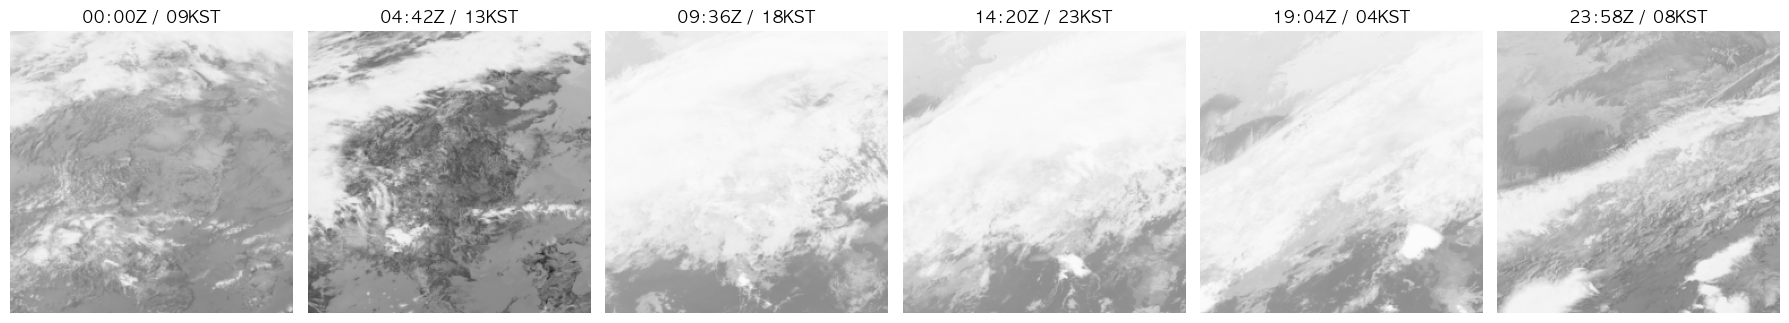

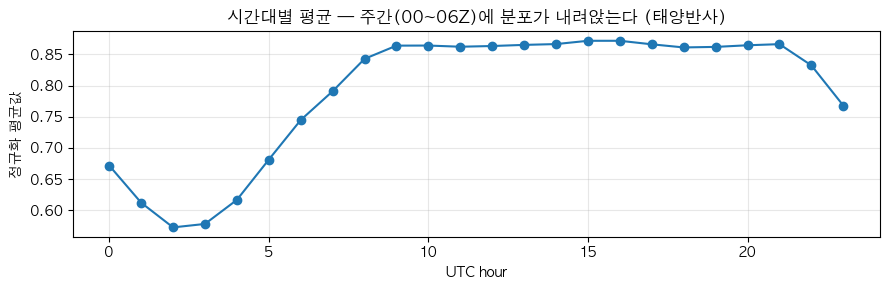

In [4]:
# ============================================================================
# 이 셀이 하는 일: 원본 밝기값(uint16 계열)을 0~1 로 옮기고, 그 결과를 눈으로 확인
#   1) 전체 프레임 기준 min/max 로 정규화
#   2) 시간대별 샘플 6장을 나란히 그려 하루가 어떻게 변하는지 본다
#   3) 시간대별 평균을 꺾은선으로 그려 '주야 전환'을 드러낸다
# ============================================================================

# --- 1) 정규화 -------------------------------------------------------------
# 원본 값은 대략 14800~16400 범위의 관측 계수(raw digital number)다. 이대로 신경망에
# 넣으면 학습이 불안정하다. 뒤에서 쓰는 장치들이 모두 0~1 을 전제로 하기 때문이다.
#   - ConvLSTM 의 activation='tanh' 는 입력이 크면 곧바로 포화(saturate)된다
#   - 손실 함수의 tf.image.ssim(..., max_val=1.0) 은 '값의 최대치가 1' 이라고 가정한다
#
# float() 로 감싸는 이유: frames.min() 은 numpy 스칼라(np.float32)라 print 출력이
# 지저분하고 나눗셈에서 dtype 이 딸려 들어간다. 파이썬 float 로 못 박아 둔다.
GMIN, GMAX = float(frames.min()), float(frames.max())
print(f'global min={GMIN}, max={GMAX}')

# 주의: min/max 를 '프레임마다' 따로 구하지 않고 '전체 프레임 하나의 기준'으로 쓴다.
#   프레임별로 정규화하면 매 장이 제각각 0~1 로 늘어나면서
#   '이 시각이 저 시각보다 밝다'는 정보가 통째로 지워진다.
#   그런데 우리가 예측하려는 대상이 바로 그 '프레임 사이의 변화'다. 그래서 전역 기준을 쓴다.
def normalize(x):   return (x - GMIN) / (GMAX - GMIN)
def denormalize(x): return x * (GMAX - GMIN) + GMIN   # 현재 노트북에서는 호출하지 않는다.
                                                      # 예측값을 원래 관측 계수로 되돌려
                                                      # 물리량으로 해석할 때 쓰려고 남겨 둔 짝함수.

frames_n = normalize(frames)   # (T, H, W), 값 범위 [0, 1]

# --- 2) 하루가 어떻게 보이는지 6장만 뽑아 확인 ------------------------------
# linspace(0, T-1, 6) 은 처음과 끝을 포함해 균등 간격으로 6개 지점을 고른다.
# 실수로 나오므로 astype(int) 로 인덱스로 만든다. (앞에서 몇 장만 자르면 하루 전체를 못 본다)
idxs = np.linspace(0, len(frames_n) - 1, 6).astype(int)
fig, axes = plt.subplots(1, 6, figsize=(18, 3.2))
for ax, i in zip(axes, idxs):
  # vmin=0, vmax=1 을 반드시 고정한다.
  #   생략하면 imshow 가 '그 장의 최소~최대'를 자동으로 0~1 에 늘려 그린다(auto scaling).
  #   그러면 어두운 장면도 밝은 장면도 화면에서는 똑같이 보여서
  #   정작 확인하려던 시간대별 밝기 차이가 사라진다.
  ax.imshow(frames_n[i], cmap='gray', vmin=0, vmax=1)
  # 관측 시각은 UTC 다. (hour + 9) % 24 로 한국 시각을 함께 표기한다. %24 는 자정을 넘길 때 필요.
  ax.set_title(f'{stamps[i]:%H:%M}Z / {(stamps[i].hour+9)%24:02d}KST')
  ax.axis('off')
plt.tight_layout(); plt.show()

# --- 3) 시간대별 평균: 주야 전환을 수치로 드러낸다 --------------------------
# sw038(단파적외)은 낮에 태양 반사 성분이 섞여 값 분포 자체가 달라진다.
# 한 모델로 주야를 함께 학습하는 셈이 되므로, 그 사실을 먼저 눈으로 확인해 둔다.
#
# 아래 한 줄의 구조:
#   바깥 for h in sorted({s.hour for s in stamps}) : 데이터에 실제로 존재하는 UTC 시각들
#     - range(24) 로 하드코딩하지 않는 이유는 HOURS 필터로 일부 시간대만 남겼을 수 있어서다
#     - set 으로 중복을 없애고 sorted 로 시간순 정렬
#   안쪽 [i for i, s in enumerate(stamps) if s.hour == h] : 그 시각에 해당하는 프레임 번호들
#     - 이 번호 리스트를 frames_n[...] 에 넣으면 numpy fancy indexing 으로 해당 프레임만 뽑힌다
#   .mean() : 뽑힌 프레임 전체(장수 x 세로 x 가로)의 평균 한 값
hourly = [frames_n[[i for i, s in enumerate(stamps) if s.hour == h]].mean()
          for h in sorted({s.hour for s in stamps})]
plt.figure(figsize=(9, 3))
plt.plot(sorted({s.hour for s in stamps}), hourly, marker='o')
plt.xlabel('UTC hour'); plt.ylabel('정규화 평균값'); plt.grid(alpha=.3)
# 그래프가 00~06Z 구간에서 푹 꺼지면 그 시간대가 주간(09~15 KST)이라는 뜻이다.
plt.title('시간대별 평균 — 주간(00~06Z)에 분포가 내려앉는다 (태양반사)')
plt.tight_layout(); plt.show()

In [5]:
# ============================================================================
# Persistence 베이스라인 = "다음 프레임은 지금과 똑같다" 고 답하는, 학습이 전혀 없는 예측 모델
#
# 왜 이걸 재는가:
#   나중에 나올 ConvLSTM 의 MAE 0.004 라는 숫자만 봐서는 잘한 건지 알 수 없다.
#   시험 점수 80점이 좋은지는 반평균을 알아야 판단할 수 있는 것과 같다.
#   그 반평균 역할을 하는 것이 Persistence 다.
#
# 아래 식을 두 가지로 읽을 수 있다는 점이 핵심이다.
#   |frames_n[t+1] - frames_n[t]|
#     (1) 데이터 관점 : 2분 동안 실제로 얼마나 변했는가
#     (2) 모델 관점   : '현재 프레임을 그대로 제출한 예측' 의 오차
#   ConvLSTM 도 같은 정답(frames_n[t+1])을 맞히려 하므로 같은 잣대로 비교할 수 있다.
#
# 특히 우리 모델은 '예측 = 마지막 프레임 + Δ' 라는 잔차 구조라서,
# Δ 를 0 으로 두면 출력이 Persistence 와 완전히 같아진다.
# 즉 Persistence 는 임의로 고른 상대가 아니라 이 모델의 출발점이며,
# 학습이란 'Δ 를 0 에서 얼마나 개선하는가' 를 찾는 과정이다.
#
# 결측으로 끊긴 지점(세그먼트 경계)은 시간 간격이 2분이 아니라 12분이므로 제외한다.
# 포함하면 12분치 변화가 섞여 베이스라인이 실제보다 나빠 보이고, 모델이 부당하게 유리해진다.
# ============================================================================

def ssim_metric(a, b):
  """두 이미지 묶음의 평균 SSIM(구조적 유사도). 1 에 가까울수록 닮았다."""
  # tf.image.ssim 은 (배치, 높이, 너비, 채널) 4차원을 요구한다.
  # 들어오는 값은 (N, H, W) 라 채널 축이 없으므로 [..., None] 으로 맨 뒤에 1 을 붙인다.
  #   (N, H, W) -> (N, H, W, 1)
  a = a[..., None].astype(np.float32)
  b = b[..., None].astype(np.float32)
  # max_val=1.0 : 픽셀 최대값이 1 이라는 뜻. 앞 셀에서 0~1 로 정규화했기 때문에 성립한다.
  # float() 로 감싸 텐서가 아닌 파이썬 숫자로 꺼낸다(그래야 print 와 리스트 저장이 깔끔).
  return float(tf.reduce_mean(tf.image.ssim(a, b, max_val=1.0)))


# 비교할 (현재, 다음) 프레임 번호 쌍을 만든다.
#   바깥 for s, e in SEGMENTS : 결측 없이 이어지는 구간 하나씩
#   안쪽 for t in range(s, e - 1) : 그 구간 안에서 t 와 t+1 짝짓기
#     - e 가 아니라 e-1 까지만 도는 이유: t+1 이 구간을 벗어나면 안 되기 때문이다.
#       (e 는 구간의 '끝 다음' 번호라 마지막 유효 프레임은 e-1 이고, 그 짝은 e-2 가 마지막)
#   결과적으로 구간을 넘나드는 쌍은 애초에 만들어지지 않는다.
pairs = [(t, t + 1) for s, e in SEGMENTS for t in range(s, e - 1)]

# MAE: 두 프레임의 픽셀별 차이의 절댓값 평균. 작을수록 덜 변했다 = 예측이 쉬웠다.
mae_list = [np.mean(np.abs(frames_n[j] - frames_n[i])) for i, j in pairs]
# SSIM: 위 함수는 (N, H, W) 를 받으므로, 한 장짜리도 [None] 으로 앞에 배치 축을 붙여 (1, H, W) 로 만든다.
ssim_list = [ssim_metric(frames_n[i][None], frames_n[j][None]) for i, j in pairs]

# 전체 쌍 수(len-1)와 실제 사용한 쌍 수의 차이가 곧 '경계에서 버린 쌍' 개수다.
print(f'연속 쌍 {len(pairs)}개 (전체 {len(frames_n)-1}쌍 중 경계 {len(frames_n)-1-len(pairs)}쌍 제외)')
print(f'Persistence  MAE = {np.mean(mae_list):.5f}   SSIM = {np.mean(ssim_list):.4f}')

# --- 주간/야간을 나눠 난이도 차이를 확인 -------------------------------------
# sw038 은 낮에 태양 반사가 섞여 프레임 간 변화 자체가 커진다 = 예측이 더 어렵다.
mae_arr = np.array(mae_list)
# day: 각 쌍이 주간인지 표시하는 True/False 배열(boolean mask).
#   pairs 의 앞 번호 i 기준으로 UTC 시각이 6시 전이면 주간(한국시각 09~15시)으로 본다.
#   mae_arr[day] 는 True 인 자리만, mae_arr[~day] 는 그 반대만 골라낸다(~ 는 논리 부정).
day = np.array([stamps[i].hour < 6 for i, _ in pairs])
print(f'  주간(00~06Z) MAE = {mae_arr[day].mean():.5f}')
print(f'  야간(06~24Z) MAE = {mae_arr[~day].mean():.5f}   -> 주간이 '
      f'{mae_arr[day].mean()/mae_arr[~day].mean():.1f}배 어렵다')
# 참고: HOURS 로 시간대를 걸러 한쪽만 남기면 day 가 전부 True 또는 False 가 되어
#       위 두 줄의 평균이 nan 이 된다(빈 배열의 평균). 그때는 이 비교를 건너뛰면 된다.
print('→ 구름 이동이 느려 베이스라인이 의외로 강하다. 모델은 이 수치를 이겨야 의미가 있다.')

2026-08-12 03:54:59.691092: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-08-12 03:54:59.691145: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-08-12 03:54:59.691162: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-08-12 03:54:59.691210: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-08-12 03:54:59.691229: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


연속 쌍 707개 (전체 709쌍 중 경계 2쌍 제외)
Persistence  MAE = 0.00801   SSIM = 0.9560
  주간(00~06Z) MAE = 0.01470
  야간(06~24Z) MAE = 0.00574   -> 주간이 2.6배 어렵다
→ 구름 이동이 느려 베이스라인이 의외로 강하다. 모델은 이 수치를 이겨야 의미가 있다.


In [6]:
# ============================================================================
# 이 셀이 하는 일: 프레임 더미 -> 신경망이 먹을 수 있는 (입력, 정답) 쌍 무더기
#
# 한 윈도우 w 는 이런 문제 하나다:
#     입력  frames[w : w+IN_FRAMES]   (과거 4장)
#     정답  frames[w + IN_FRAMES]     (그다음 1장)
#
# 두 가지를 곱해서 샘플 수를 불린다.
#   (1) 윈도우를 한 칸씩 밀며 만든다  -> 프레임 한 장이 여러 문제에 재사용된다
#   (2) 각 윈도우를 96x96 패치로 잘라 나눈다 -> 문제 하나가 9개로 늘어난다
#
# 왜 패치로 자르나? 메모리를 아끼려는 게 아니다(겹치는 부분을 중복 저장해 오히려 늘어난다).
#   250x250 통째로 : 샘플   698개, X 0.70 GB
#   96x96 패치     : 샘플 6,282개, X 0.93 GB   <- 샘플이 9배
# 학습 샘플이 9배가 되는 것이 핵심이고, 모델이 fully-conv 라 작게 배워도
# 추론은 250x250 전체를 한 번에 할 수 있어서 손해가 없다.
#
# 윈도우는 반드시 '하나의 연속 구간 안'에서만 만든다 (결측 지점을 건너뛰지 않도록).
# ============================================================================

def window_starts(segments, in_frames=IN_FRAMES):
  """세그먼트 경계를 넘지 않는 윈도우 시작 인덱스 목록 (시간순)."""
  starts = []
  for s, e in segments:
    # w 는 s 부터 시작하되, 정답 프레임 w+in_frames 가 구간 안(e-1 이하)이어야 한다.
    #   w + in_frames <= e - 1  ->  w <= e - in_frames - 1  ->  range 의 끝은 e - in_frames
    # 구간이 in_frames 보다 짧으면 range 가 비어 아무것도 안 만들어진다(에러 없음).
    starts.extend(range(s, e - in_frames))
  return starts


def build_dataset(frames_n, starts, in_frames=IN_FRAMES, patch=PATCH, stride=STRIDE):
  T, H, W = frames_n.shape

  # 패치의 시작 좌표 목록. H - patch + 1 에서 '+1' 이 중요하다.
  #   H=250, patch=96, stride=77 일 때
  #     +1 없으면 range(0, 154, 77) = [0, 77]        -> 마지막 패치 끝이 173, 오른쪽 77칸이 안 쓰인다
  #     +1 있으면 range(0, 155, 77) = [0, 77, 154]   -> 154+96 = 250, 오른쪽 끝에 딱 맞는다
  # stride(77) < patch(96) 이므로 이웃 패치끼리 19칸씩 겹친다. 겹쳐야 전 영역을 덮을 수 있다.
  ys = list(range(0, H - patch + 1, stride))
  xs = list(range(0, W - patch + 1, stride))

  # 최종 샘플 수 = 윈도우 수 x 세로 패치 수 x 가로 패치 수 (698 x 3 x 3 = 6282)
  n = len(starts) * len(ys) * len(xs)

  # list.append 후 np.array 하면 피크 메모리가 2배가 된다 -> 미리 할당해 바로 채운다
  #   (0.93 GB 짜리를 만들 때 리스트 방식은 순간 1.85 GB 를 쓴다)
  X = np.empty((n, in_frames, patch, patch, 1), dtype=np.float32)
  Y = np.empty((n, patch, patch, 1), dtype=np.float32)

  k = 0   # 지금까지 채운 샘플 개수 = 다음에 쓸 자리
  for w in starts:
    seq = frames_n[w:w + in_frames]   # (in_frames, H, W)  이 윈도우의 입력 4장
    tgt = frames_n[w + in_frames]     # (H, W)             이 윈도우의 정답 1장
    for y in ys:
      for x in xs:
        # X[k] 의 shape 는 (in_frames, patch, patch, 1) 이고,
        # X[k, ..., 0] 은 마지막 채널 축을 벗겨낸 (in_frames, patch, patch) 다.
        #   '...' (Ellipsis) 는 "가운데 축은 전부 그대로" 라는 뜻.
        # 오른쪽 seq[:, y:y+patch, x:x+patch] 도 (in_frames, patch, patch) 라 모양이 맞는다.
        # 채널 축을 따로 붙이는 이유는 Conv/ConvLSTM 이 채널 차원을 요구하기 때문이다.
        X[k, ..., 0] = seq[:, y:y + patch, x:x + patch]
        Y[k, ..., 0] = tgt[y:y + patch, x:x + patch]      # (patch, patch)
        k += 1
  return X, Y


# 실제로 몇 조각이 나오고 영역을 얼마나 덮는지 확인용 출력.
#   세로(shape[1])와 가로(shape[2])를 각각 계산한다. 정사각형이 아닌 데이터에서도 맞도록.
#   커버리지 = (세로로 덮은 길이 x 가로로 덮은 길이) / (전체 넓이). 1.0 이면 빠짐없이 덮은 것.
#   stride 를 patch 와 같게 두면(96) 격자가 2x2 로 줄어 좌상단 59% 만 학습된다.
_ys = list(range(0, frames_n.shape[1] - PATCH + 1, STRIDE))   # 세로 시작점
_xs = list(range(0, frames_n.shape[2] - PATCH + 1, STRIDE))   # 가로 시작점
_cov = ((max(_ys) + PATCH) * (max(_xs) + PATCH)) / (frames_n.shape[1] * frames_n.shape[2])
print(f'패치 격자 {len(_ys)}x{len(_xs)} = {len(_ys)*len(_xs)}개/프레임, '
      f'커버리지 {_cov * 100:.0f}%')

패치 격자 3x3 = 9개/프레임, 커버리지 100%


In [7]:
# 시간 순서 유지 분할 (무작위 셔플 금지)
starts = window_starts(SEGMENTS)
cut = int(len(starts) * 0.8)

# val 은 cut 에서 IN_FRAMES 만큼 띄워서 시작한다.
# 그렇지 않으면 val 첫 윈도우의 '입력'이 train 마지막 윈도우의 '타깃'을 포함해 누수가 된다.
train_starts = starts[:cut]
val_starts   = starts[cut + IN_FRAMES:]
print(f'윈도우 {len(starts)}개 -> train {len(train_starts)} / val {len(val_starts)} '
      f'(경계 {IN_FRAMES}개는 누수 방지로 버림)')
print(f'train 기간: {stamps[train_starts[0]]:%H:%M} ~ {stamps[train_starts[-1]+IN_FRAMES]:%H:%M}')
print(f'val   기간: {stamps[val_starts[0]]:%H:%M} ~ {stamps[val_starts[-1]+IN_FRAMES]:%H:%M}')

X_train, Y_train = build_dataset(frames_n, train_starts)
X_val,   Y_val   = build_dataset(frames_n, val_starts)

print(f'\ntrain: {X_train.shape} {Y_train.shape}  ({(X_train.nbytes+Y_train.nbytes)/1e9:.2f} GB)')
print(f'val  : {X_val.shape} {Y_val.shape}  ({(X_val.nbytes+Y_val.nbytes)/1e9:.2f} GB)')

윈도우 698개 -> train 558 / val 136 (경계 4개는 누수 방지로 버림)
train 기간: 00:00 ~ 19:00
val   기간: 19:02 ~ 23:58

train: (5022, 4, 96, 96, 1) (5022, 96, 96, 1)  (0.93 GB)
val  : (1224, 4, 96, 96, 1) (1224, 96, 96, 1)  (0.23 GB)


In [8]:
# (2: 잔차 + SSIM 손실) 흐릿함 완화
#  - 모델은 '변화량 Δ'만 예측하고 마지막 입력 프레임에 더한다 -> 입력의 선명함을 계승
#    예측 = 마지막 입력 프레임 + Δ   (residual skip)
#  - 손실 = 0.5*MAE + 0.5*(1-SSIM)   (엣지/구조 보존 유도)
#  - 주의(A): Metal 에서 5D BatchNorm 비호환이라 BN 은 쓰지 않는다.

def ssim_mae_loss(y_true, y_pred):
  mae = tf.reduce_mean(tf.abs(y_true - y_pred))
  ssim = tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))
  return 0.5 * mae + 0.5 * (1.0 - ssim)


class TakeLastFrame(keras.layers.Layer):
  """시퀀스에서 마지막 시점만 뽑는다.  (B, T, H, W, C) -> (B, H, W, C)

  layers.Lambda(lambda t: t[:, -1]) 로도 되지만 쓰지 않는다.
  Lambda 는 파이썬 바이트코드로 저장돼 다른 환경에서 불러오기 어렵고,
  Keras 공식 문서도 이런 경우 Layer 상속을 권장한다.
  compute_output_shape 로 출력 모양을 직접 알려주므로 Keras 2/3 양쪽에서 안전하다.
  """

  def call(self, x):
    return x[:, -1]

  def compute_output_shape(self, input_shape):
    # (B, T, H, W, C) 에서 시간축(T)만 빼고 그대로 -> (B, H, W, C)
    return (input_shape[0],) + tuple(input_shape[2:])


def build_model(in_frames=IN_FRAMES, filters=FILTERS, h=PATCH, w=PATCH):
  # ── 왜 keras.Sequential 이 아니라 Functional API 인가? ───────────────────────
  # Sequential 은 '레이어 -> 레이어 -> ...' 로 한 줄로만 이어지는 구조다.
  # 이 모델은 마지막에 두 텐서를 '더한다':
  #     예측 = (입력의 마지막 프레임) + (신경망이 예측한 변화량 Δ)
  # 즉 입력에서 갈래(branch)가 나오고 끝에서 합쳐지는(merge) 구조라 일직선이 아니다.
  # 이런 잔차(residual) 구조는 Sequential 로 표현할 수 없어 Functional API 를 쓴다.
  #
  # ── layers.XXX(...)(텐서)  의 소괄호가 두 번 나오는 이유 ─────────────────────
  # Keras 레이어는 '함수처럼 호출할 수 있는 객체' 다. 두 단계로 나뉜다:
  #     conv = layers.ConvLSTM2D(...)   # (1) 레이어 '객체' 를 만든다 (설정만)
  #     x = conv(inp)                   # (2) 그 객체에 입력 텐서를 통과시킨다
  # 이 둘을 한 줄로 붙이면  layers.ConvLSTM2D(...)(inp)  가 되고,
  # 그래서 소괄호가 (생성)(호출) 두 번 나오는 것이다.
  # 아래에서는 이해를 돕기 위해 (1)과 (2)를 일부러 두 줄로 풀어 썼다.
  #
  # ── 입력 크기를 왜 h, w 로 받는가 (중요) ────────────────────────────────────
  # 예전에는 shape=(in_frames, None, None, 1) 로 두어 어떤 크기든 받게 했지만,
  # Keras 3(TensorFlow 2.16+, Colab 기본)에서는 다음 에러로 막힌다.
  #     ValueError: ConvLSTM layers only support static input shapes
  #                 for the spatial dimension.
  # 그래서 크기를 고정해 만든다. 대신 가중치는 입력 크기와 무관하므로,
  # 추론할 때 다른 크기로 모델을 새로 만들고 set_weights 로 옮기면
  # '작게 배워 크게 추론' 하는 성질은 그대로 유지된다. (아래 마지막 셀 참고)

  inp = keras.Input(shape=(in_frames, h, w, 1))   # 입력 텐서 (시간, 높이, 너비, 채널)

  lstm1 = layers.ConvLSTM2D(filters, (3, 3), padding='same',
                            return_sequences=True, activation='tanh')   # (1) 객체 생성
  x = lstm1(inp)                                                        # (2) 통과: 시퀀스 그대로 출력

  lstm2 = layers.ConvLSTM2D(filters, (3, 3), padding='same',
                            return_sequences=False, activation='tanh')
  x = lstm2(x)                                                          # 마지막 시점 하나만 출력

  to_delta = layers.Conv2D(1, (3, 3), padding='same',
                           activation=None, dtype='float32')           # 출력 1채널, 음수 가능하므로 linear
  delta = to_delta(x)                                                  # 변화량 Δ

  take_last = TakeLastFrame(dtype='float32')                           # 입력에서 마지막 프레임만 슬라이스
  last = take_last(inp)

  out = layers.Add(dtype='float32')([last, delta])                     # 예측 = 마지막 프레임 + Δ (잔차 합치기)

  model = keras.Model(inputs=inp, outputs=out)

  # legacy.Adam 은 Keras 2 에만 있고 Apple Silicon 에서 더 빠르다.
  # Keras 3 에는 이 네임스페이스가 없으므로 표준 Adam 으로 넘어간다.
  try:
    opt = keras.optimizers.legacy.Adam(1e-3)
  except Exception:
    opt = keras.optimizers.Adam(1e-3)
  model.compile(optimizer=opt, loss=ssim_mae_loss, metrics=['mae'])
  return model

model = build_model()          # 학습용: PATCH x PATCH (96x96)
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 4, 96, 96, 1)]       0         []                            
                                                                                                  
 conv_lstm2d (ConvLSTM2D)    (None, 4, 96, 96, 16)        9856      ['input_1[0][0]']             
                                                                                                  
 conv_lstm2d_1 (ConvLSTM2D)  (None, 96, 96, 16)           18496     ['conv_lstm2d[0][0]']         
                                                                                                  
 take_last_frame (TakeLastF  (None, 96, 96, 1)            0         ['input_1[0][0]']             
 rame)                                                                                        

In [9]:
callbacks = [
  keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
  keras.callbacks.ReduceLROnPlateau(monitor='val_loss', patience=4, factor=0.5),
]

steps = int(np.ceil(len(X_train) / BATCH))
print(f'{len(X_train)}샘플 / batch {BATCH} = {steps} step/epoch, 최대 {EPOCHS} epoch')
print(f'M1 Pro 기준 1 epoch 약 4분 -> 예상 {EPOCHS * 4}분 (EarlyStopping 으로 더 짧아질 수 있다)\n')

t0 = time.time()
history = model.fit(
  X_train, Y_train,
  validation_data=(X_val, Y_val),
  epochs=EPOCHS, batch_size=BATCH,
  callbacks=callbacks, verbose=1,
)
print(f'\n학습 시간: {(time.time() - t0)/60:.1f}분 ({len(history.history["loss"])} epoch 실행)')

5022샘플 / batch 16 = 314 step/epoch, 최대 4 epoch
M1 Pro 기준 1 epoch 약 4분 -> 예상 16분 (EarlyStopping 으로 더 짧아질 수 있다)

Epoch 1/4


2026-08-12 03:55:18.446409: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


314/314 [==============================] - 226s 704ms/step - loss: 0.0187 - mae: 0.0082 - val_loss: 0.0101 - val_mae: 0.0046 - lr: 0.0010
Epoch 2/4
314/314 [==============================] - 245s 781ms/step - loss: 0.0111 - mae: 0.0061 - val_loss: 0.0092 - val_mae: 0.0044 - lr: 0.0010
Epoch 3/4
314/314 [==============================] - 215s 685ms/step - loss: 0.0104 - mae: 0.0057 - val_loss: 0.0088 - val_mae: 0.0040 - lr: 0.0010
Epoch 4/4
314/314 [==============================] - 217s 690ms/step - loss: 0.0102 - mae: 0.0056 - val_loss: 0.0086 - val_mae: 0.0039 - lr: 0.0010

학습 시간: 15.1분 (4 epoch 실행)


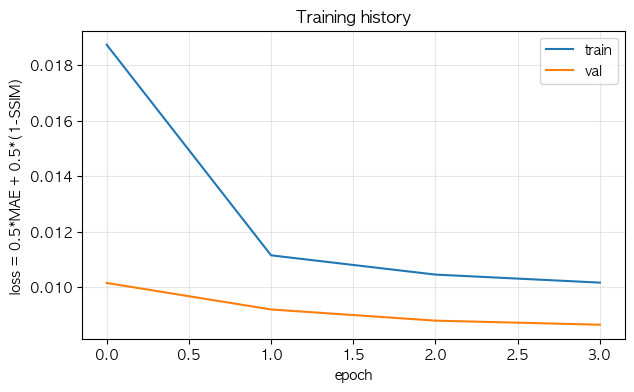

[Val] ConvLSTM    MAE = 0.00386   SSIM = 0.9866
[Val] Persistence MAE = 0.00623   SSIM = 0.9595
→ MAE 기준 모델이 베이스라인보다 우수 (+38.1%)


In [10]:
# 학습 곡선
plt.figure(figsize=(7, 4))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('epoch'); plt.ylabel('loss = 0.5*MAE + 0.5*(1-SSIM)')
plt.legend(); plt.grid(alpha=.3); plt.title('Training history')
plt.show()

# 검증셋에서 모델 vs Persistence 비교 (MAE 낮을수록 / SSIM 높을수록 좋음)
pred_val = np.clip(model.predict(X_val, batch_size=BATCH, verbose=0), 0, 1)
model_mae  = float(np.mean(np.abs(pred_val - Y_val)))
pers_mae   = float(np.mean(np.abs(X_val[:, -1] - Y_val)))            # 예측=입력 마지막 프레임
model_ssim = ssim_metric(pred_val[..., 0], Y_val[..., 0])
pers_ssim  = ssim_metric(X_val[:, -1, ..., 0], Y_val[..., 0])

print(f'[Val] ConvLSTM    MAE = {model_mae:.5f}   SSIM = {model_ssim:.4f}')
print(f'[Val] Persistence MAE = {pers_mae:.5f}   SSIM = {pers_ssim:.4f}')
print(f'→ MAE 기준 모델이 베이스라인보다 {"우수" if model_mae < pers_mae else "열등"} '
      f'({(pers_mae - model_mae) / pers_mae * 100:+.1f}%)')

추론용 모델 재구성: 250x250, 가중치 28,497개 이전 완료
입력 23:50~23:56 -> 예측 23:58 UTC


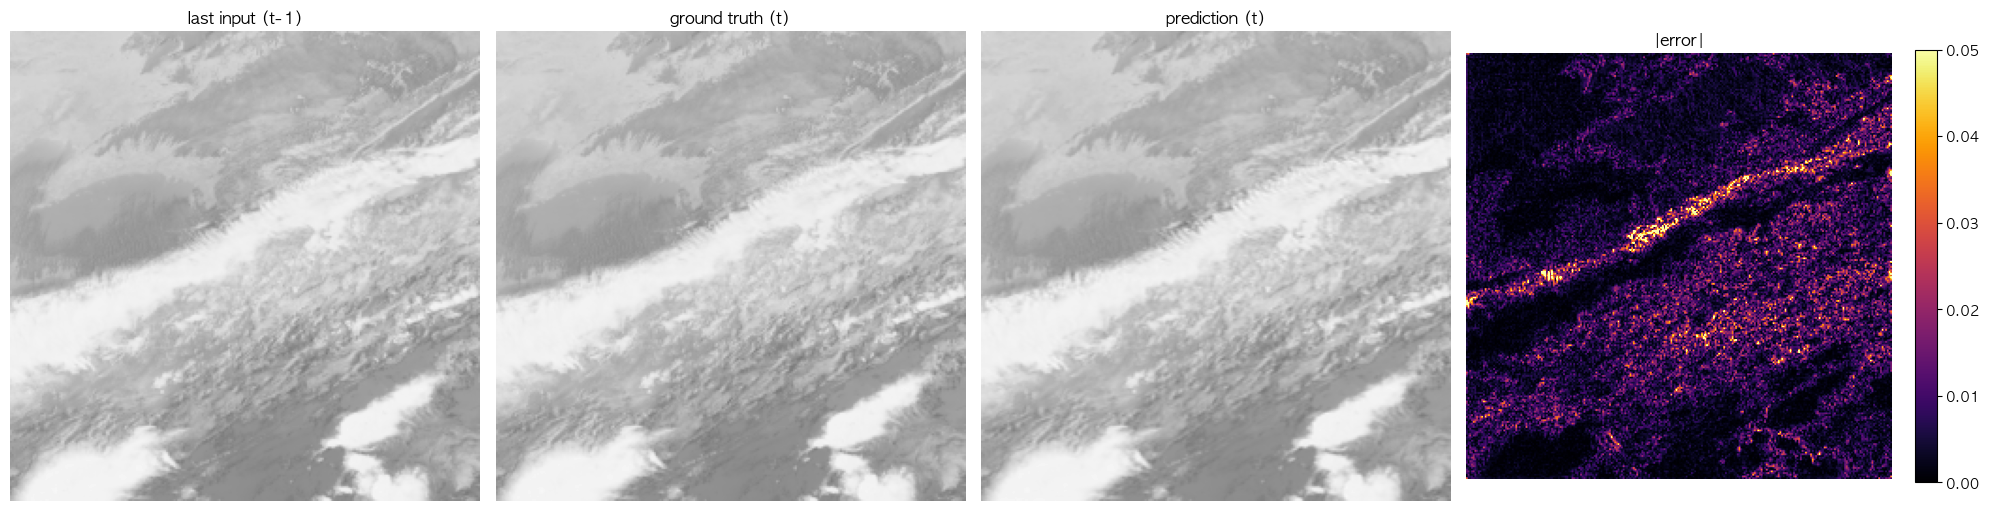

full-frame  ConvLSTM    MAE = 0.00662  SSIM = 0.9728
full-frame  Persistence MAE = 0.01091  SSIM = 0.9204


In [11]:
# 전체 프레임 다음 시점 예측
# 마지막 '연속 구간' 안에서 뽑아야 입력 4장이 실제로 2분 간격이다.
seg_s, seg_e = SEGMENTS[-1]
if seg_e - seg_s < IN_FRAMES + 1:
  raise ValueError('마지막 연속 구간이 너무 짧다. 다른 세그먼트를 골라라.')

t_pred = seg_e - 1                                        # 예측 대상 시점
seq = frames_n[t_pred - IN_FRAMES:t_pred][None, ..., None]   # (1, IN_FRAMES, H, W, 1)
true_next = frames_n[t_pred]

# 학습은 96x96 패치로 했지만 추론은 250x250 전체로 한다.
# ConvLSTM/Conv 의 가중치는 입력 크기와 무관하므로(커널을 전 위치에서 공유),
# 전체 크기로 모델을 새로 만들고 학습된 가중치를 그대로 옮기면 된다.
#   - Keras 2 라면 입력 shape 에 None 을 써서 한 모델로 처리할 수도 있지만,
#     Keras 3 의 ConvLSTM 은 높이/너비에 None 을 허용하지 않아 이 방식이 양쪽에서 안전하다.
#   - 파라미터 개수가 같아야 set_weights 가 성공한다(같으면 구조가 일치한다는 뜻).
infer_model = build_model(h=frames_n.shape[1], w=frames_n.shape[2])
infer_model.set_weights(model.get_weights())
print(f'추론용 모델 재구성: {frames_n.shape[1]}x{frames_n.shape[2]}, '
      f'가중치 {infer_model.count_params():,}개 이전 완료')

pred_next = np.clip(infer_model.predict(seq, verbose=0)[0, ..., 0], 0, 1)   # 잔차합이 [0,1] 벗어날 수 있어 clip

print(f'입력 {stamps[t_pred-IN_FRAMES]:%H:%M}~{stamps[t_pred-1]:%H:%M} '
      f'-> 예측 {stamps[t_pred]:%H:%M} UTC')

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(frames_n[t_pred - 1], cmap='gray', vmin=0, vmax=1); axes[0].set_title('last input (t-1)')
axes[1].imshow(true_next, cmap='gray', vmin=0, vmax=1);            axes[1].set_title('ground truth (t)')
axes[2].imshow(pred_next, cmap='gray', vmin=0, vmax=1);            axes[2].set_title('prediction (t)')
im = axes[3].imshow(np.abs(pred_next - true_next), cmap='inferno', vmin=0, vmax=0.05)
axes[3].set_title('|error|')
plt.colorbar(im, ax=axes[3], fraction=.046)
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

pers_full = float(np.mean(np.abs(frames_n[t_pred - 1] - true_next)))
print(f'full-frame  ConvLSTM    MAE = {float(np.mean(np.abs(pred_next - true_next))):.5f}  '
      f'SSIM = {ssim_metric(pred_next[None], true_next[None]):.4f}')
print(f'full-frame  Persistence MAE = {pers_full:.5f}  '
      f'SSIM = {ssim_metric(frames_n[t_pred-1][None], true_next[None]):.4f}')